包导入，matplotlib中文支持

In [26]:
import os
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import soundfile as sf

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

输入信号：drumloop.wav前1秒
卷积信号：4096采样长度的低通滤波器
目标：在已知卷积信号下，从卷积输出中反卷积出输入信号

采样率 = 48000 Hz，输入长度 n_x = 296472
低通核：16 点，截止 8 kHz，直流增益 sum(h) = 1.0000
卷积输出长度 = 296487，带噪 SNR = 39.99 dB


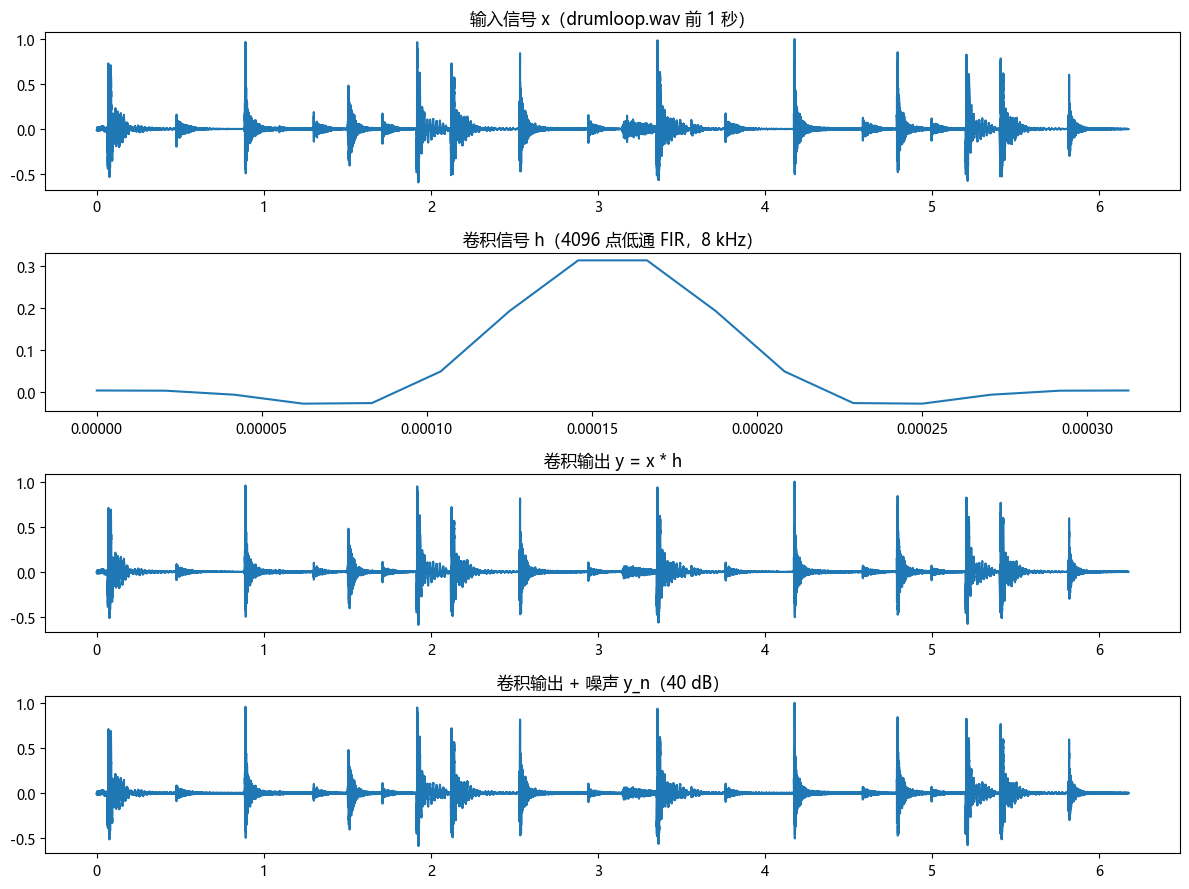

In [27]:
def snr_db(x, x_hat):
    """信噪比（dB）：SNR = 10*log10(||x||^2 / ||x - x_hat||^2)"""
    return 10 * np.log10(np.sum(x ** 2) / np.sum((x - x_hat) ** 2))


def add_noise(sig, snr_target=40.0, seed=42):
    """添加高斯白噪声，使带噪信号 SNR 达到 snr_target (dB)"""
    rng = np.random.default_rng(seed)
    p_sig = np.mean(sig ** 2)
    p_noise = p_sig / (10 ** (snr_target / 10))
    return sig + rng.normal(0.0, np.sqrt(p_noise), sig.shape)


# ---- 输入信号：drumloop.wav 前 1 秒 ----
# 同时兼容「工作区根目录」与「笔记本所在目录」两种运行环境
candidates = [
    'qwqdsp/tests/work_dir/input/drumloop.wav',
    '../../tests/work_dir/input/drumloop.wav',
]
wav_path = next(p for p in candidates if os.path.exists(p))

x, sr = sf.read(wav_path)
if x.ndim > 1:
    x = x.mean(axis=1)          # 多声道取平均
# x = x[:sr * 1]                  # 前 1 秒
x = x / np.max(np.abs(x))       # 归一化到 [-1, 1]（保证正则化参数尺度一致）
n_x = len(x)
print(f'采样率 = {sr} Hz，输入长度 n_x = {n_x}')

# ---- 卷积核：4096 点低通 FIR（firwin，截止频率 8 kHz）----
n_h = 16
fc = 8000.0
h = signal.firwin(n_h, fc, fs=sr)
print(f'低通核：{n_h} 点，截止 {fc/1000:.0f} kHz，直流增益 sum(h) = {h.sum():.4f}')

# ---- 卷积输出（full 模式，长度 n_x + n_h - 1）----
y = np.convolve(x, h)
y_n = add_noise(y, 40.0)
print(f'卷积输出长度 = {len(y)}，带噪 SNR = {snr_db(y, y_n):.2f} dB')

# ---- 波形预览 ----
fig, axes = plt.subplots(4, 1, figsize=(12, 9))
t = np.arange(n_x) / sr
axes[0].plot(t, x)
axes[0].set_title('输入信号 x（drumloop.wav 前 1 秒）')
axes[1].plot(np.arange(n_h) / sr, h)
axes[1].set_title('卷积信号 h（4096 点低通 FIR，8 kHz）')
axes[2].plot(np.arange(len(y)) / sr, y)
axes[2].set_title('卷积输出 y = x * h')
axes[3].plot(np.arange(len(y)) / sr, y_n)
axes[3].set_title('卷积输出 + 噪声 y_n（40 dB）')
plt.tight_layout()
plt.show()

# 1. 维纳滤波（Wiener）
$$\hat{X}(\omega) = \left( \frac{H^*(\omega)}{\vert{}H(\omega)\vert{}^2 + K} \right) Y(\omega)$$
$K$ 以 $\mathrm{mean}(|H|^2)$ 归一化，防止 $|H|$ 接近 0 处放大噪声。

维纳滤波：SNR = 21.68 dB


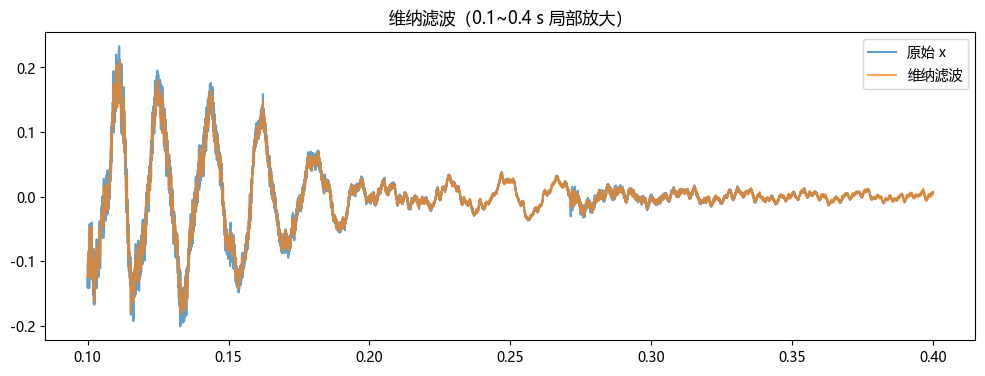

In [28]:
def deconv_wiener(y, h, n_x, k=0.1):
    """维纳滤波：X_hat = conj(H)/(|H|^2 + K) * Y（一维）

    nfft 取不小于 len(y) 的 2 的幂；K 以 mean(|H|^2) 归一化。
    """
    nfft = 1 << (len(y) - 1).bit_length()
    Y = np.fft.rfft(y, nfft)
    H = np.fft.rfft(h, nfft)
    K = k * np.mean(np.abs(H) ** 2)
    G = np.conj(H) / (np.abs(H) ** 2 + K)
    return np.fft.irfft(G * Y, nfft)[:n_x]


x_wiener = deconv_wiener(y_n, h, n_x)
print(f'维纳滤波：SNR = {snr_db(x, x_wiener):.2f} dB')

# ---- 波形对比（取 0.1~0.4 秒放大显示，便于观察瞬态）----
t0, t1 = 0.1, 0.4
i0, i1 = int(t0 * sr), int(t1 * sr)
plt.figure(figsize=(12, 4))
plt.plot(t[i0:i1], x[i0:i1], label='原始 x', alpha=0.7)
plt.plot(t[i0:i1], x_wiener[i0:i1], label='维纳滤波', alpha=0.7)
plt.legend()
plt.title('维纳滤波（0.1~0.4 s 局部放大）')
plt.show()

# 2. 全变差（Total Variation, TV）正则化反卷积
TV 正则化使用导数的 $L1$ 范数，适合鼓点这类**瞬态稀疏**信号（保留尖锐瞬态，抑制噪声）：
$$\min_x \frac{1}{2}\Vert{}Ax - y\Vert{}_2^2 + \lambda \sum_i \vert{}\nabla x_i\vert{}$$
用 Chambolle-Pock 原始-对偶算法求解。卷积算子 $A$（full 模式）与其伴随 $A^*$（翻转核 valid 模式）都用 FFT 实现。

In [29]:
def grad1d(x):
    """一维前向差分梯度，边界外视为 0"""
    g = np.zeros_like(x)
    g[:-1] = x[1:] - x[:-1]
    return g


def div1d(p):
    """梯度算子的负伴随（一维散度）：<∇x, p> = <x, -div p>"""
    out = np.zeros_like(p)
    out[1:] += p[:-1] - p[1:]
    out[0] += -p[0]
    return out


def deconv_tv(y, h, n_x, lam, num_iter=300):
    """全变差正则化反卷积（一维，Chambolle-Pock 原始-对偶算法）

    min_x 1/2||Ax - y||^2 + λ·Σ|∇x|
    A：x → fftconvolve(x, h, 'full')（长度 n_x + n_h - 1）
    A*：p → fftconvolve(p, h[::-1], 'valid')（长度 n_x）
    """
    h_flip = h[::-1]

    # 步长：||K||² ≤ ||A||² + ||∇||² ≤ 1 + 4 = 5，取 στ < 1/5
    sigma = tau = 0.99 / np.sqrt(5.0)
    theta = 1.0

    x_hat = y[:n_x].copy()
    xbar = x_hat.copy()
    pA = np.zeros_like(y)      # 保真项对偶变量
    pq = np.zeros_like(x_hat)  # TV 对偶变量

    for _ in range(num_iter):
        # ---- 对偶更新 ----
        Axbar = signal.fftconvolve(xbar, h, mode='full')
        gxbar = grad1d(xbar)
        pA = (pA + sigma * (Axbar - y)) / (1 + sigma)
        # TV：投影到 |q| ≤ λ
        vq = pq + sigma * gxbar
        pq = vq * np.minimum(1.0, lam / (np.abs(vq) + 1e-12))

        # ---- 原始更新：x ← x - τ(A* pA - div q) ----
        Apx = signal.fftconvolve(pA, h_flip, mode='valid')
        x_new = x_hat - tau * (Apx - div1d(pq))

        # ---- 外推 ----
        xbar = x_new + theta * (x_new - x_hat)
        x_hat = x_new

    return x_hat


# ---- 验证 A 与其伴随 A* 的关系：<Ax, p> = <x, A*p> ----
h_flip = h[::-1]
x_t = np.random.default_rng(0).standard_normal(n_x)
p_t = np.random.default_rng(1).standard_normal(len(y))
lhs = np.dot(signal.fftconvolve(x_t, h, mode='full'), p_t)
rhs = np.dot(x_t, signal.fftconvolve(p_t, h_flip, mode='valid'))
print(f'伴随验证：<Ax,p>={lhs:.6f}  <x,A*p>={rhs:.6f}')

伴随验证：<Ax,p>=374.548817  <x,A*p>=374.548817


TV 反卷积：SNR = 23.03 dB


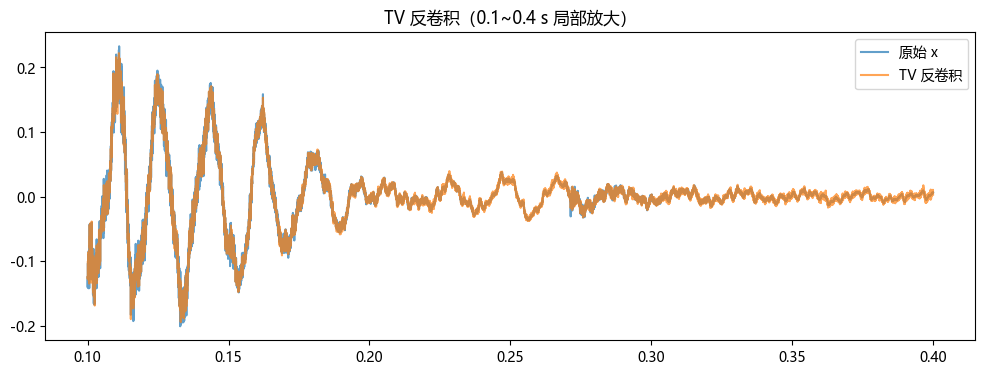

In [30]:
x_tv = deconv_tv(y_n, h, n_x, lam=1e-7, num_iter=500)
print(f'TV 反卷积：SNR = {snr_db(x, x_tv):.2f} dB')

plt.figure(figsize=(12, 4))
plt.plot(t[i0:i1], x[i0:i1], label='原始 x', alpha=0.7)
plt.plot(t[i0:i1], x_tv[i0:i1], label='TV 反卷积', alpha=0.7)
plt.legend()
plt.title('TV 反卷积（0.1~0.4 s 局部放大）')
plt.show()

方法                  SNR (dB)
--------------------------------
维纳滤波                   21.68
TV 反卷积                 23.03


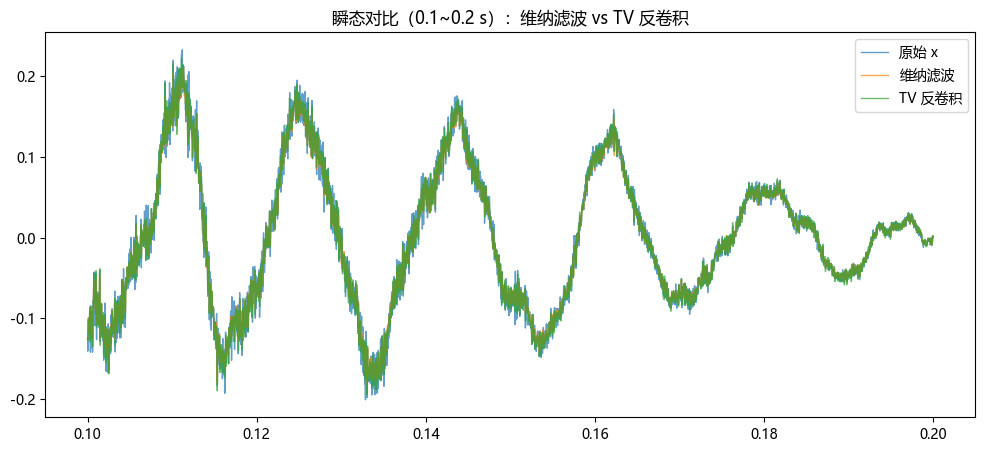

In [31]:
# ---- 各方法 SNR 汇总 ----
rows = [
    ('维纳滤波', snr_db(x, x_wiener)),
    ('TV 反卷积', snr_db(x, x_tv)),
]
print('方法                  SNR (dB)')
print('-' * 32)
for name, snr in rows:
    print(f'{name:<18}{snr:>10.2f}')

# ---- 瞬态细节对比（0.1~0.2 s 紧聚焦，观察鼓点瞬态的保留程度）----
ta, tb = 0.1, 0.2
ia, ib = int(ta * sr), int(tb * sr)
plt.figure(figsize=(12, 5))
plt.plot(t[ia:ib], x[ia:ib], label='原始 x', alpha=0.7, linewidth=1)
plt.plot(t[ia:ib], x_wiener[ia:ib], label='维纳滤波', alpha=0.7, linewidth=1)
plt.plot(t[ia:ib], x_tv[ia:ib], label='TV 反卷积', alpha=0.7, linewidth=1)
plt.legend()
plt.title('瞬态对比（0.1~0.2 s）：维纳滤波 vs TV 反卷积')
plt.show()

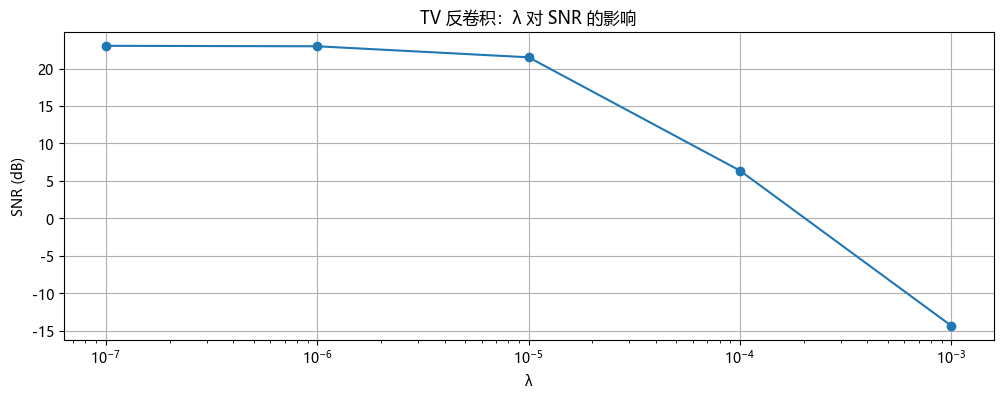

最优 λ = 1.00e-07，SNR = 23.03 dB


In [32]:
# ---- TV λ 扫描：正则化强度对带噪反卷积的影响 ----
lams = np.logspace(-7, -3, 5)
snrs_tv = [snr_db(x, deconv_tv(y_n, h, n_x, lam, num_iter=500)) for lam in lams]

plt.figure(figsize=(12, 4))
plt.semilogx(lams, snrs_tv, 'o-')
plt.xlabel('λ')
plt.ylabel('SNR (dB)')
plt.title('TV 反卷积：λ 对 SNR 的影响')
plt.grid(True)
plt.show()

best = int(np.argmax(snrs_tv))
print(f'最优 λ = {lams[best]:.2e}，SNR = {snrs_tv[best]:.2f} dB')

In [33]:
# !!! agent禁止运行此单元格 !!!
from IPython.display import Audio, display
display(Audio(x, rate=sr))
display(Audio(y_n, rate=sr))
display(Audio(x_wiener, rate=sr))
display(Audio(x_tv, rate=sr))

# 结论
维纳滤波比TV更优，TV在滤波器阻带对比维纳滤波仍然有较高的噪声，虽然SNR更高